In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\data.csv")

In [4]:
df.head()

,question,documents,response,label
0,In what school district is Governor John R. Ro...,['Governor John R. Rogers High School is a hig...,"Governor John R. Rogers High School, named aft...",GROUNDED
1,whiich Australian racing driver won the 44-lap...,"['Colin Fleming (born April 21, 1984 in San Di...",Daniel Ricciardo won the 44-lap race for the R...,GROUNDED
2,What star of Parks and Recreation appeared in ...,['Pioneer Park is a 44-acre (109-ha) city park...,"Nick Offerman, who played the role of Ron Swan...",GROUNDED
3,Which genus of flowering plant is found in an ...,['Actaea arizonica is a species of flowering p...,Crocosmia is found in an environment further s...,GROUNDED
4,In what year did the man who shot the Chris St...,['Dennis Bruce Allen (7 November 1951 – 13 Apr...,"Dennis Bruce Allen, the man who shot Chris Sto...",GROUNDED


In [5]:
X = df.drop("label",axis=1)
y = df["label"]

# Method 1 Using simple Model

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [7]:
def documents_to_text(documents):
    if isinstance(documents, (list, tuple, np.ndarray)):
        return " ".join(map(str, documents))
    return str(documents)


X_train_text = (
    X_train["question"].fillna("") + " " +
    X_train["documents"].apply(documents_to_text) + " " +
    X_train["response"].fillna("")
)

X_test_text = (
    X_test["question"].fillna("") + " " +
    X_test["documents"].apply(documents_to_text) + " " +
    X_test["response"].fillna("")
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

Accuracy: 0.9230769230769231
Macro F1: 0.32
                    precision    recall  f1-score   support

          GROUNDED       0.92      1.00      0.96       348
      HALLUCINATED       0.00      0.00      0.00        25
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.92       377
         macro avg       0.31      0.33      0.32       377
      weighted avg       0.85      0.92      0.89       377



c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

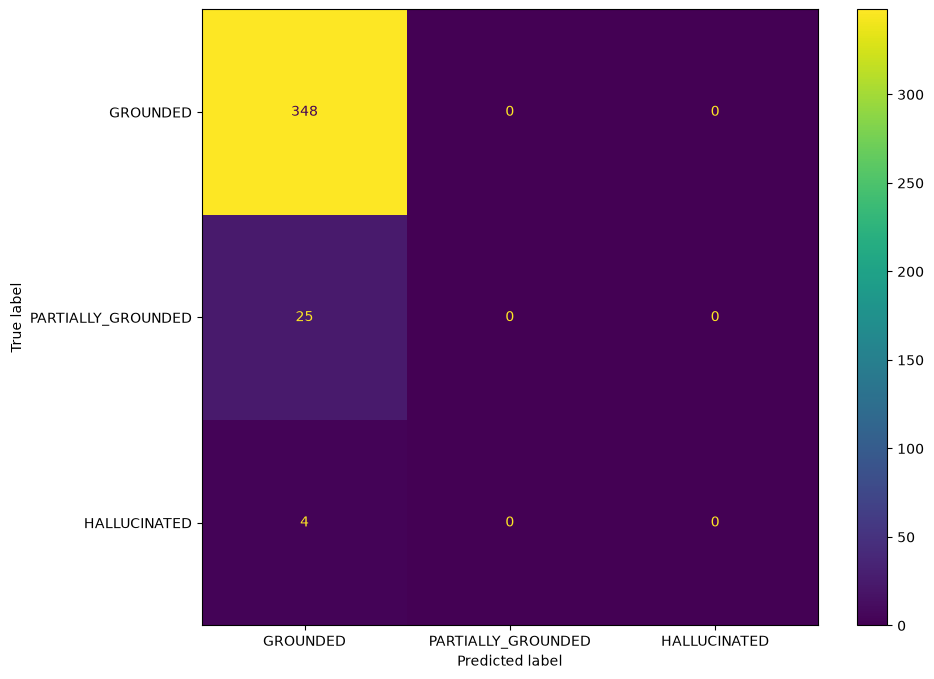

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

# Method 2 Using Stratify to y

Accuracy: 0.9151193633952255
Macro F1: 0.3185595567867036
                    precision    recall  f1-score   support

          GROUNDED       0.92      1.00      0.96       345
      HALLUCINATED       0.00      0.00      0.00        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.92       377
         macro avg       0.31      0.33      0.32       377
      weighted avg       0.84      0.92      0.87       377



c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

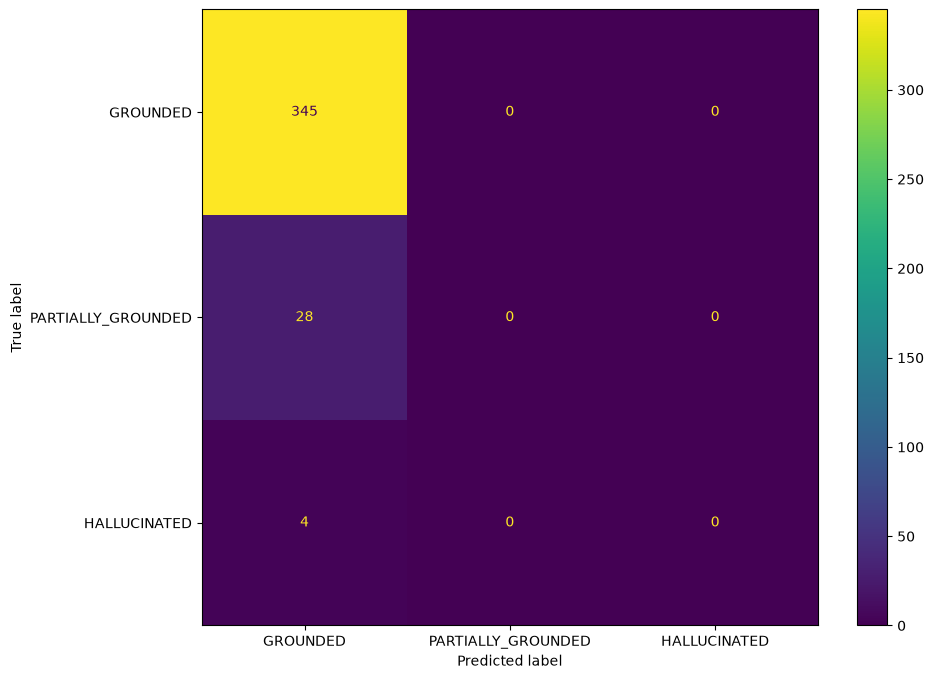

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)



model = LogisticRegression(
    max_iter=1000
)

def documents_to_text(documents):
    if isinstance(documents, (list, tuple, np.ndarray)):
        return " ".join(map(str, documents))
    return str(documents)


X_train_text = (
    X_train["question"].fillna("") + " " +
    X_train["documents"].apply(documents_to_text) + " " +
    X_train["response"].fillna("")
)

X_test_text = (
    X_test["question"].fillna("") + " " +
    X_test["documents"].apply(documents_to_text) + " " +
    X_test["response"].fillna("")
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

# Method 3 using  class_weight="balanced" and startify to y

Accuracy: 0.896551724137931
Macro F1: 0.33356108917906674
                    precision    recall  f1-score   support

          GROUNDED       0.92      0.98      0.95       345
      HALLUCINATED       0.11      0.04      0.05        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.90       377
         macro avg       0.34      0.34      0.33       377
      weighted avg       0.85      0.90      0.87       377



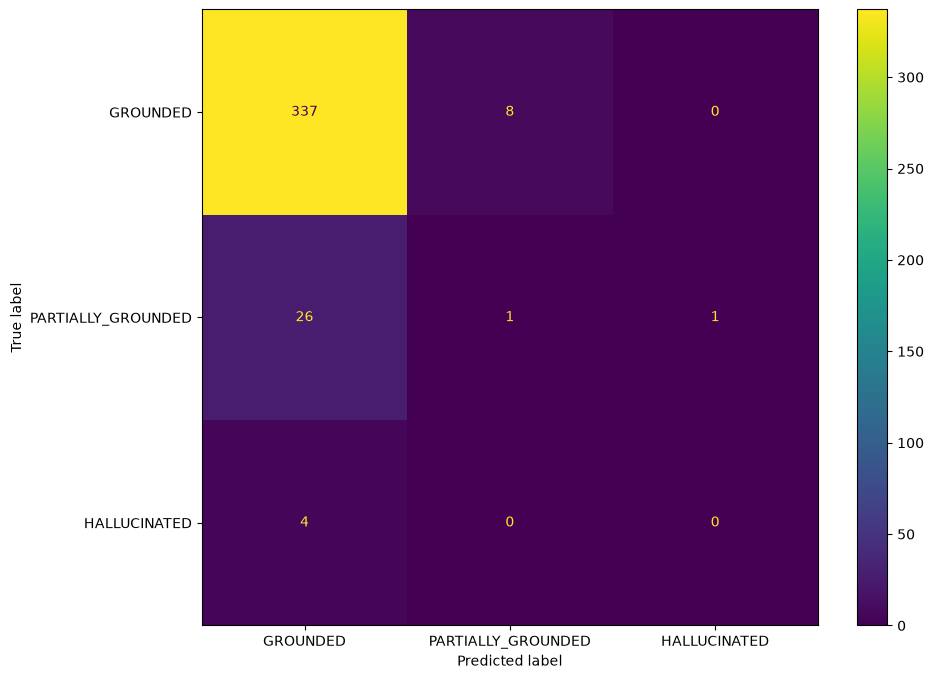

In [12]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

# Using Smote

In [13]:
from imblearn.over_sampling import SMOTE

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

In [15]:
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_smote).value_counts())

Before:
label
GROUNDED              1379
HALLUCINATED           112
PARTIALLY_GROUNDED      15
Name: count, dtype: int64

After:
label
GROUNDED              1379
HALLUCINATED          1379
PARTIALLY_GROUNDED    1379
Name: count, dtype: int64


Accuracy: 0.9045092838196287
Macro F1: 0.3170618317061832
                    precision    recall  f1-score   support

          GROUNDED       0.92      0.99      0.95       345
      HALLUCINATED       0.00      0.00      0.00        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.90       377
         macro avg       0.31      0.33      0.32       377
      weighted avg       0.84      0.90      0.87       377



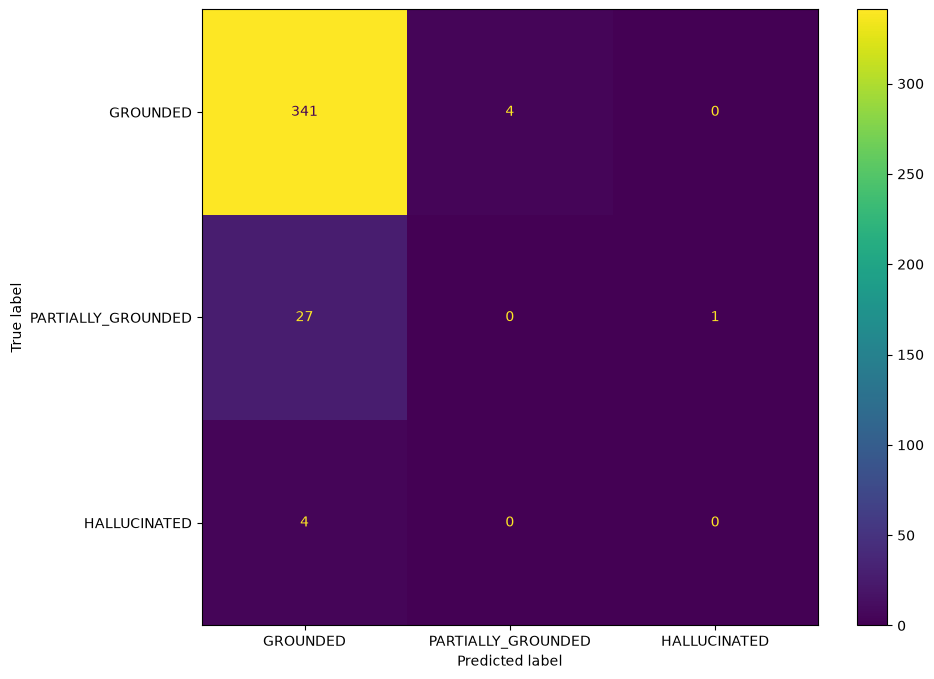

In [17]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()